## Exercice 1

1 a)

In [1]:

import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler

In [2]:
n=100
X_sam=np.random.uniform(0, 1, 100)
eps_sam = np.random.normal(0,1,100)



In [3]:
sig=0.2


In [4]:
def f(x):
    return ((x**2)* 2**(x-1) - (x-0.5)**3)* np.sin(10*x)

In [5]:
def Y(f , x , sig , eps):
    return f(x) + sig * eps

In [6]:
Y_values= Y(f, X_sam , sig , eps_sam )

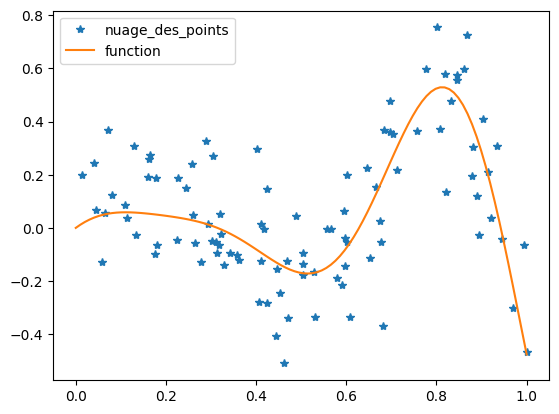

In [7]:
x_data= np.linspace(0,1, 100)
plt.plot(X_sam , Y_values , "*", label = "nuage_des_points")
plt.plot(x_data , f(x_data) ,  label="function")
plt.legend()
plt.show()


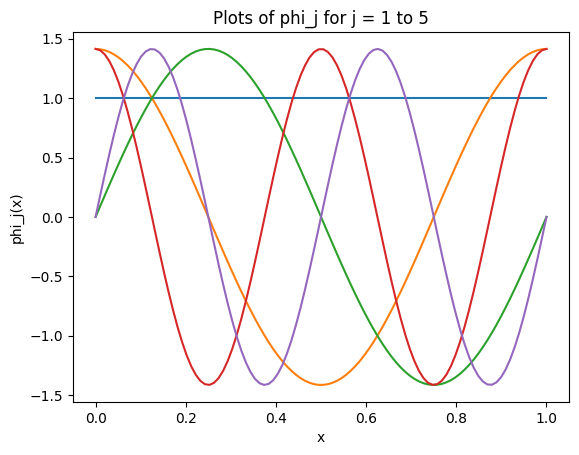

In [8]:
def phi_j(x, j):
    if j == 1:
        return np.ones_like(x)  # Return an array of ones with the same shape as x
    elif (j % 2) == 0:
        return np.sqrt(2) * np.cos(2 * np.pi * (j / 2) * x)
    else:
        return np.sqrt(2) * np.sin(2 * np.pi * ((j - 1) / 2) * x)


# Plotting the functions
for j in range(1, 6):
    plt.plot(x_data, phi_j(x_data, j), label=f'phi_j with j={j}')
    

plt.xlabel('x')
plt.ylabel('phi_j(x)')
plt.title('Plots of phi_j for j = 1 to 5')
plt.show()


In [9]:
def theta_j(x, phi_j, y, j):
    n = len(x)                
    phi = phi_j(x, j) 
    theta = (1/n) * np.sum(Y_values * phi)  
    return theta


In [10]:
def f_hat(x, X, phi_j, y, theta_j, N):
    total = 0
    for j in range(1, N + 1):  
        total += theta_j(X, phi_j , y , j) * phi_j(x, j)  
    return total

In [11]:
N = [5,10,15,20,30,40,50,60,70]

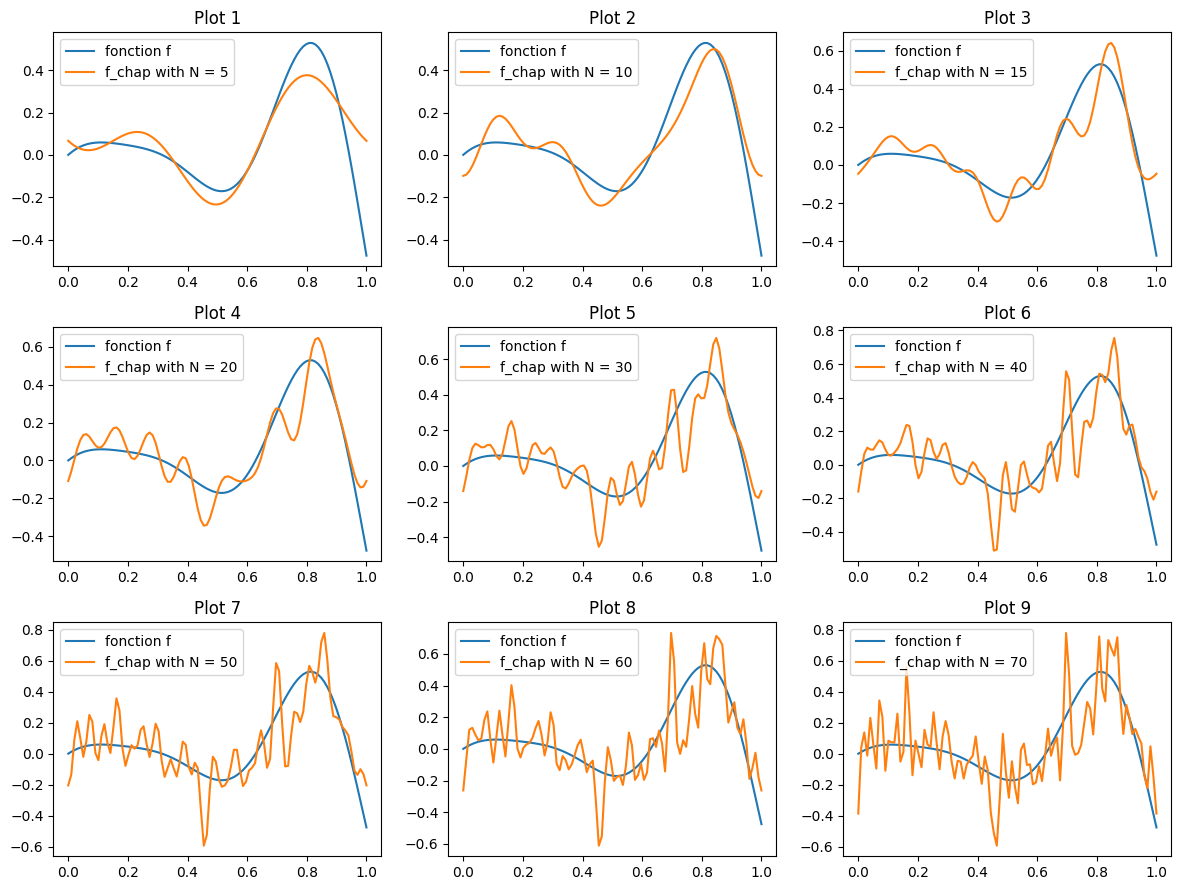

In [12]:

fig, axes = plt.subplots(3, 3, figsize=(12, 9))  
for i in range(9):
    row = i // 3  
    col = i % 3   
    
    axes[row, col].plot(x_data, f(x_data), label="fonction f")
    axes[row, col].plot(x_data, f_hat(x_data,X_sam,phi_j, Y_values,theta_j,  N[i]), label=f"f_chap with N = {N[i]}")
    axes[row, col].legend()
    axes[row, col].set_title(f"Plot {i+1}")  

plt.tight_layout()  
plt.show()

In [13]:
def theta_j_val(X, phi_j, Y_train, j):
    n = len(X)  
    phi = phi_j(X, j)  
    theta = (1/n) * np.sum(Y_train * phi) 
    return theta

In [14]:


def block_cross_validate(X, Y_values, phi_j, theta_j_validation, N_values, n_blocks=5):
    n_samples = len(X)
    block_size = n_samples // n_blocks  
    results = {N: [] for N in N_values}  
    
    for block in range(n_blocks):
        
        test_start = block * block_size
        test_end = test_start + block_size if block < n_blocks - 1 else n_samples
        
        
        X_train = np.concatenate([X[:test_start], X[test_end:]])
        Y_train = np.concatenate([Y_values[:test_start], Y_values[test_end:]])
        X_test = X[test_start:test_end]
        Y_test = Y_values[test_start:test_end]
        
        for N in N_values:
            
            f_hat_predictions = f_hat(X_test, X_train, phi_j, Y_train, theta_j_validation, N)
            
            
            mse = np.mean((Y_test - f_hat_predictions) ** 2)
            results[N].append(mse)  
    
    # Average results across all blocks
    average_results = {N: np.mean(mse_list) for N, mse_list in results.items()}
    return average_results







The best N value is 6 with an average MSE of 0.0392


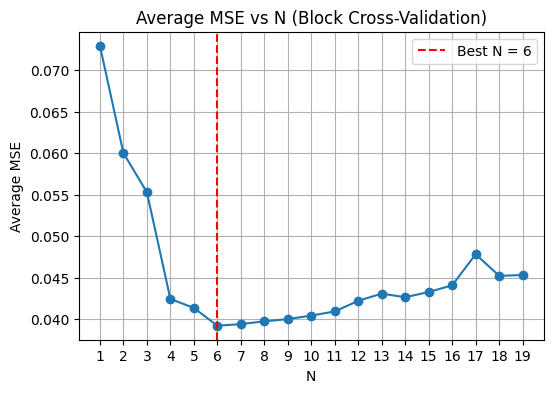

In [15]:
N_values = range(1, 20) 
n_blocks = 5


average_results = block_cross_validate(X_sam, Y_values, phi_j, theta_j_val, N_values, n_blocks=n_blocks)





best_N = min(average_results, key=average_results.get)
print(f"The best N value is {best_N} with an average MSE of {average_results[best_N]:.4f}")


plt.figure(figsize=(6, 4))
plt.plot(list(average_results.keys()), list(average_results.values()), marker='o')
plt.title('Average MSE vs N (Block Cross-Validation)')
plt.xlabel('N')
plt.ylabel('Average MSE')
plt.xticks(list(average_results.keys()))
plt.grid()
plt.axvline(best_N, color='r', linestyle='--', label=f'Best N = {best_N}')
plt.legend()
plt.show()

In [16]:
def get_best_N(average_results):
    """Helper function to get the best N based on the average results."""
    return min(average_results, key=average_results.get)

def cv_repeat(n_iterations, X, Y_values, phi_j, theta_j_val, N_values, n_blocks=5):
    optimal_N_values = []

    for iteration in range(n_iterations): 
    
        indices = np.arange(len(X))  
        np.random.shuffle(indices)  
        X_shuffled = X[indices]  
        Y_values_shuffled = Y_values[indices]  

        average_results = block_cross_validate(X_shuffled, Y_values_shuffled, phi_j, theta_j_val, N_values, n_blocks)
        
        
        optimal_N = min(average_results, key=average_results.get)
      
        
        optimal_N_values.append(optimal_N)

    return optimal_N_values



In [17]:

N_values = range(1, 26)  
n_iterations = 200  
optimal_N_values = cv_repeat(n_iterations, X_sam, Y_values, phi_j, theta_j_val, N_values, n_blocks=5)



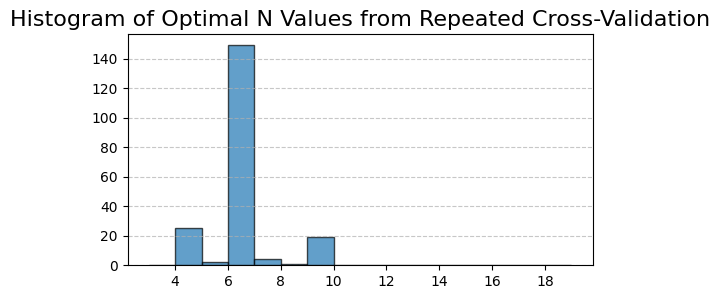

In [18]:

plt.figure(figsize=(6, 3))
plt.hist(optimal_N_values, bins=np.arange(3, 20, 1), edgecolor='black', alpha=0.7)
plt.title('Histogram of Optimal N Values from Repeated Cross-Validation', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.show()

In [19]:

data = pd.read_csv('iris.csv' , delimiter=',')



In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


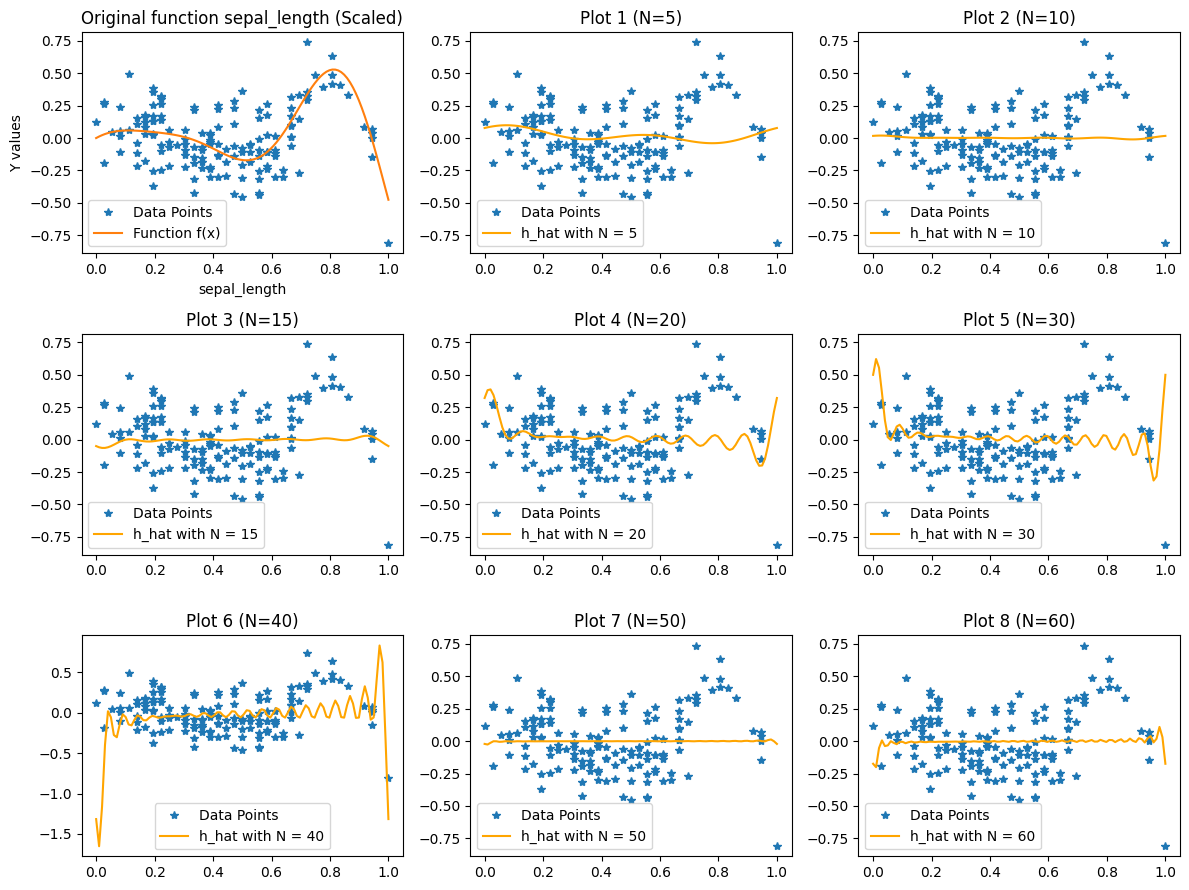

In [21]:


feature_name = 'sepal_length' 
X = data[feature_name].values.reshape(-1, 1)  


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X).flatten() 

sig = 0.2  
eps_sam = np.random.randn(len(X_scaled))  


def f(x):
    return (x**2 * 2**(x-1) - (x-0.5)**3) * np.sin(10*x)


def Y(f, x, sig, eps):
    return f(x) + sig * eps


Y_values = Y(f, X_scaled, sig, eps_sam)

def theta_j_val(X, phi_j, Y_train, j):
    X = np.asarray(X)  
    Y_train = np.asarray(Y_train)
    
    n = len(X)  
    phi = phi_j(X, j) 
    
    if phi.ndim > 1: 
        theta = (1/n) * np.sum(Y_train[:, np.newaxis] * phi, axis=0) 
    else:
        theta = (1/n) * np.sum(Y_train * phi)  

    return theta

def phi_j(x, j):
    x = np.asarray(x)  
    
    if j == 1:
        return np.ones_like(x)  
    elif (j % 2) == 0:
        result = np.sqrt(2) * np.cos(2 * np.pi * (j / 2) * x)
        return result
    else:
        result = np.sqrt(2) * np.sin(2 * np.pi * ((j - 1) / 2) * x)
        return result


def h_hat(x, phi_j, Y_train, theta_j, N):
    x = np.asarray(x) 
    result = np.zeros_like(x)  
    
    for j in range(1, N + 1):  
        phi_j_values = phi_j(x, j)  
        result += phi_j_values * theta_j  

    return result


N = [5,10,15,20,30,40,50,60,70]


fig, axes = plt.subplots(3, 3, figsize=(12, 9))


axes[0, 0].plot(X_scaled, Y_values, "*", label="Data Points")
axes[0, 0].plot(np.linspace(0, 1, 100), f(np.linspace(0, 1, 100)), label="Function f(x)")
axes[0, 0].set_xlabel(feature_name)
axes[0, 0].set_ylabel("Y values")
axes[0, 0].legend()
axes[0, 0].set_title(f"Original function {feature_name} (Scaled)")

for i in range(1, 9):
    row = i // 3
    col = i % 3

 
    theta_j = theta_j_val(X_scaled, phi_j, Y_values, N[i - 1]) 

   
    axes[row, col].plot(X_scaled, Y_values, "*", label="Data Points")

    estimated_Y_values = h_hat(np.linspace(0, 1, 100), phi_j, Y_values, theta_j, N[i - 1])
    axes[row, col].plot(np.linspace(0, 1, 100), estimated_Y_values, label=f"h_hat with N = {N[i - 1]}", color='orange')

    axes[row, col].legend()
    axes[row, col].set_title(f"Plot {i} (N={N[i - 1]})")

plt.tight_layout()
plt.savefig('a')
plt.show()


In [22]:
N_values = range(1, 20)  
n_blocks = 5


best_N = N_values[np.argmin(average_results)]
print(f"The best N value is {best_N} with an average MSE of {average_results[best_N]:.4f}")


The best N value is 1 with an average MSE of 0.0729
